# Incremental Capstone 13 - Natural Language Processing: Incremental Capstone

## Problem Scenario
IMDB receives thousands of customer reviews and feedback. However, manually analyzing this data is inefficient. The goal of this capstone is to develop an NLP-powered sentiment analysis system that automatically classifies reviews as positive or negative. 

The labeled data set consists of 50,000 IMDB movie reviews, specially selected for sentiment analysis. The sentiment of reviews is binary, meaning the IMDB rating < 5 results in a sentiment score of 0, and rating >=7 have a sentiment score of 1. No individual movie has more than 30 reviews. The 25,000 review labeled training set does not include any of the same movies as the 25,000 review test set.

### Problem Objective
The objective of this capstone is to analyze reviews, extract insights, and understand sentiment.

## Notebook Setup

### Imports

In [80]:
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
)

import tensorflow as tf
import tf_keras as keras
from tf_keras.models import Sequential
from tf_keras.layers import (
    Embedding, LSTM,  Dense,  Dropout, Bidirectional, Input
)
from tf_keras.preprocessing.sequence import pad_sequences
from tf_keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tf_keras.regularizers import l2

#NLP Libraries
import nltk
from nltk.corpus import stopwords, wordnet
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import tokenizers
from tokenizers import normalizers
from tokenizers.normalizers import NFD, StripAccents, Lowercase
import transformers
from transformers import (
    BertTokenizerFast, AutoTokenizer, TFAutoModelForSequenceClassification, TFTrainingArguments
)

stop_words = set(stopwords.words('english'))

np.random.seed(320)
tf.random.set_seed(320)

In [35]:
print("Transformers:", transformers.__version__)
print("TensorFlow:", tf.__version__)
print("Keras", keras.__version__)     # Should match TF 2.20

Transformers: 4.41.2
TensorFlow: 2.20.0
Keras 2.20.1


We had to downgrade the Transformers package versioning due to Tensorflow being deprecated in the major 5.x+ versions! Have to keep this in mind for future projects using pre-trained models. Also have to switch to python3.10 or python3.11 versioning as well. Which also lead to 

### Configuration

In [ ]:
# Configure GPU settings
gpus = tf.config.list_physical_devices('GPU')
print(gpus)

if gpus:
    try:
        # Use only GPU 0
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpus[0], True)

        print(f'Using GPU: {gpus[0]}')
        print('Memory growth enabled')

    except RuntimeError as e:
        print(e)

[]


In [37]:
pd.set_option("display.max_columns", None)

In [78]:
#Trigger for training on expensive models WARNING! LONG LOADING! GPU recommended
is_training = False

## 1. EDA

### 1.1 Load Data

In [38]:
LABELED_TRAINING_URL = "https://raw.githubusercontent.com/gperdrizet/FSA_devops/refs/heads/main/data/unit5/labeledTrainData.tsv"
training_df = pd.read_csv(LABELED_TRAINING_URL, sep="\t")
training_df

,id,sentiment,review
0,5814_8,1,"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally starts is only on for 20 minutes or so excluding the Smooth Criminal sequence and Joe Pesci is convincing as a psychopathic all powerful drug lord. Why he wants MJ dead so bad is beyond me. Because MJ overheard his plans? Nah, Joe Pesci's character ranted that he wanted people to know it is he who is supplying drugs etc so i dunno, maybe he just hates MJ's music.<br /><br />Lots of cool things in this like MJ turning into a car and a robot and the whole Speed Demon sequence. Also, the director must have had the patience of a saint when it came to filming the kiddy Bad sequence as usually directors hate working with one kid let alone a whole bunch of them performing a complex dance scene.<br /><br />Bottom line, this movie is for people who like MJ on one level or another (which i think is most people). If not, then stay away. It does try and give off a wholesome message and ironically MJ's bestest buddy in this movie is a girl! Michael Jackson is truly one of the most talented people ever to grace this planet but is he guilty? Well, with all the attention i've gave this subject....hmmm well i don't know because people can be different behind closed doors, i know this for a fact. He is either an extremely nice but stupid guy or one of the most sickest liars. I hope he is not the latter."
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hines is a very entertaining film that obviously goes to great effort and lengths to faithfully recreate H. G. Wells' classic book. Mr. Hines succeeds in doing so. I, and those who watched his film with me, appreciated the fact that it was not the standard, predictable Hollywood fare that comes out every year, e.g. the Spielberg version with Tom Cruise that had only the slightest resemblance to the book. Obviously, everyone looks for different things in a movie. Those who envision themselves as amateur \""critics\"" look only to criticize everything they can. Others rate a movie on more important bases,like being entertained, which is why most people never agree with the \""critics\"". We enjoyed the effort Mr. Hines put into being faithful to H.G. Wells' classic novel, and we found it to be very entertaining. This made it easy to overlook what the \""critics\"" perceive to be its shortcomings."""
2,7759_3,0,"The film starts with a manager (Nicholas Bell) giving welcome investors (Robert Carradine) to Primal Park . A secret project mutating a primal animal using fossilized DNA, like ¨Jurassik Park¨, and some scientists resurrect one of nature's most fearsome predators, the Sabretooth tiger or Smilodon . Scientific ambition turns deadly, however, and when the high voltage fence is opened the creature escape and begins savagely stalking its prey - the human visitors , tourists and scientific.Meanwhile some youngsters enter in the restricted area of the security center and are attacked by a pack of large pre-historical animals which are deadlier and bigger . In addition , a security

In [39]:
UNLABELED_TESTING_URL = "https://raw.githubusercontent.com/gperdrizet/FSA_devops/refs/heads/main/data/unit5/unlabeledTestData.tsv"
testing_df = pd.read_csv(UNLABELED_TESTING_URL, sep="\t")
testing_df

,id,review
0,12311_10,"Naturally in a film who's main themes are of mortality, nostalgia, and loss of innocence it is perhaps not surprising that it is rated more highly by older viewers than younger ones. However there is a craftsmanship and completeness to the film which anyone can enjoy. The pace is steady and constant, the characters full and engaging, the relationships and interactions natural showing that you do not need floods of tears to show emotion, screams to show fear, shouting to show dispute or violence to show anger. Naturally Joyce's short story lends the film a ready made structure as perfect as a polished diamond, but the small changes Huston makes such as the inclusion of the poem fit in neatly. It is truly a masterpiece of tact, subtlety and overwhelming beauty."
1,8348_2,"This movie is a disaster within a disaster film. It is full of great action scenes, which are only meaningful if you throw away all sense of reality. Let's see, word to the wise, lava burns you; steam burns you. You can't stand next to lava. Diverting a minor lava flow is difficult, let alone a significant one. Scares me to think that some might actually believe what they saw in this movie.<br /><br />Even worse is the significant amount of talent that went into making this film. I mean the acting is actually very good. The effects are above average. Hard to believe somebody read the scripts for this and allowed all this talent to be wasted. I guess my suggestion would be that if this movie is about to start on TV ... look away! It is like a train wreck: it is so awful that once you know what is coming, you just have to watch. Look away and spend your time on more meaningful content."
2,5828_4,"All in all, this is a movie for kids. We saw it tonight and my child loved it. At one point my kid's excitement was so great that sitting was impossible. However, I am a great fan of A.A. Milne's books which are very subtle and hide a wry intelligence behind the childlike quality of its leading characters. This film was not subtle. It seems a shame that Disney cannot see the benefit of making movies from more of the stories contained in those pages, although perhaps, it doesn't have the permission to use them. I found myself wishing the theater was replaying \Winnie-the-Pooh and Tigger too\"", instead. The characters voices were very good. I was only really bothered by Kanga. The music, however, was twice as loud in parts than the dialog, and incongruous to the film.<br /><br />As for the story, it was a bit preachy and militant in tone. Overall, I was disappointed, but I would go again just to see the same excitement on my child's face.<br /><br />I liked Lumpy's laugh...."""
3,7186_2,"Afraid of the Dark left me with the impression that several different screenplays were written, all too short for a feature length film, then spliced together clumsily into this Frankenstein's monster.<br /><br />At his best, the protagonist, Lucas, is creepy. As hard as it is to draw a bead on the secondary characters, they're far more sympathetic.<br /><br />Afraid of the Dark could have achieved mediocrity had it taken just one approach and seen it through -- and had it made Lucas simply psychotic and confused instead of ghoulish and off-putting. I wanted to see him packed off into an asylum so the rest of the characters could have a normal life."
4,12128_7,"A very accurate depiction of small time mob life filmed in New Jersey. The story, characters and script are believable but the acting drops the ball. Still, it's worth watching, especially for the strong images, some still with me even though I first viewed this 25 years ago.<br /><br />A young hood steps up and starts doing bigger things (tries to) but these things keep going wrong, leading the local boss to suspect that his end is being skimmed off, not a good place to be if you enjoy your health, or life.<br /><br />This is the film that introduced Joe Pesce to Martin Scorsese. Also present is that perenni

In [40]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         25000 non-null  object
 1   sentiment  25000 non-null  int64 
 2   review     25000 non-null  object
dtypes: int64(1), object(2)
memory usage: 586.1+ KB


### 1.2 Sampling Data

In [41]:
pd.set_option('display.max_colwidth', None)
training_df.sample(10)

id  sentiment  \
3692   8011_10          1   
4205    7156_1          0   
14260  10324_2          0   
17157   8927_8          1   
3977    6086_4          0   
5519     985_4          0   
17997   5613_3          0   
16381   2110_3          0   
5143    5401_2          0   
7845    3581_2          0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

Quick glance at the sample data we noticed:
- There is no proofreading, therefore misspelled/misused words will stay as written. i.e. "Don't waist your time"
- Reviews will have onomatopoeia usage. i.e. "BAM"
- There will be emphasized words to indicate tone or sarcasm. i.e. "THIS ONE IS DIFFERENT"

## 2. Preprocessing



In [42]:
df_preprocess = training_df.copy(deep=True)

### 2.1 Clean Text Data

In [43]:
#Create function to use for lemmantizer POS parameter
def get_wordnet_pos(word):
    #Map NLTK tag to WordNet tag.
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN) # Default to noun if no specific tag is found

In [ ]:
#Make a function to clean the text data
normalizer = normalizers.Sequence([NFD(), StripAccents(), Lowercase()])
lemmatizer = WordNetLemmatizer()

def clean_text(text:str, view_changes:bool=False):
    '''Clean and tokenize text using the Bert-Based-Uncased Tokenizer.

        Args:
            param1 (str): The text string to be cleaned and tokenized
            param2 (bool): an OPTIONAL print the changes between each text transformation
    '''

    changes_list = []

    if not isinstance(text, str):
        return []
    changes_list.append(f"Original: {text}")

    # Remove URLs before tokenizing
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    #Normalize text
    text = normalizer.normalize_str(text)
    changes_list.append(f"\nNormalized: {text}")

    # Tokenizer handles: lowercase, @mentions, repeated chars (e.g., sooooo -> sooo)
    tokens = word_tokenize(text)
    changes_list.append(f"\nTokenized: {tokens}")

    # Remove stopwords and single characters
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    changes_list.append(f"\nStopwords Removed: {tokens}")

    # Tokenize and lemmatize with POS tagging
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    changes_list.append(f"\nLemmatized Words: {tokens}")

    # OPTIONAL: Print the changes between each text transformation
    if view_changes:
        [print(change) for change in changes_list]

    return tokens

# For 1 row Testing
# clean_text(training_df["review"][320], True)

# Apply tokenization to entire df
df_preprocess["tokens"] = df_preprocess["review"].apply(clean_text)
df_preprocess[["review", "sentiment", "tokens"]].head()

,review,sentiment,tokens
0,"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally starts is only on for 20 minutes or so excluding the Smooth Criminal sequence and Joe Pesci is convincing as a psychopathic all powerful drug lord. Why he wants MJ dead so bad is beyond me. Because MJ overheard his plans? Nah, Joe Pesci's character ranted that he wanted people to know it is he who is supplying drugs etc so i dunno, maybe he just hates MJ's music.<br /><br />Lots of cool things in this like MJ turning into a car and a robot and the whole Speed Demon sequence. Also, the director must have had the patience of a saint when it came to filming the kiddy Bad sequence as usually directors hate working with one kid let alone a whole bunch of them performing a complex dance scene.<br /><br />Bottom line, this movie is for people who like MJ on one level or another (which i think is most people). If not, then stay away. It does try and give off a wholesome message and ironically MJ's bestest buddy in this movie is a girl! Michael Jackson is truly one of the most talented people ever to grace this planet but is he guilty? Well, with all the attention i've gave this subject....hmmm well i don't know because people can be different behind closed doors, i know this for a fact. He is either an extremely nice but stupid guy or one of the most sickest liars. I hope he is not the latter.",1,"[stuff, go, moment, mj, 've, start, listen, music, watch, odd, documentary, watch, wiz, watch, moonwalker, maybe, want, get, certain, insight, guy, thought, really, cool, eighty, maybe, make, mind, whether, guilty, innocent, moonwalker, part, biography, part, feature, film, remember, go, see, cinema, originally, release, subtle, message, mj, 's, feel, towards, press, also, obvious, message, drug, bad, m'kay., br, br, visually, impressive, course, michael, jackson, unless, remotely, like, mj, anyway, go, hate, find, boring, may, call, mj, egotist, consent, make, movie, mj, fan, would, say, make, fan, true, really, nice, him., br, br, actual, feature, film, bit, finally, start, 20, minute, exclude, ...]"
1,"\The Classic War of the Worlds\"" by Timothy Hines is a very entertaining film that obviously goes to great effort and lengths to faithfully recreate H. G. Wells' classic book. Mr. Hines succeeds in doing so. I, and those who watched his film with me, appreciated the fact that it was not the standard, predictable Hollywood fare that comes out every year, e.g. the Spielberg version with Tom Cruise that had only the slightest resemblance to the book. Obviously, everyone looks for different things in a movie. Those who envision themselves as amateur \""critics\"" look only to criticize everything they can. Others rate a movie on more important bases,like being entertained, which is why most people never agree with the \""critics\"". We enjoyed the effort Mr. Hines put into being faithful to H.G. Wells' classic novel, and we found it to be very entertaining. This made it easy to overlook what the \""critics\"" perceive to be its shortcoming

### 2.2 Extract Vocabulary

In [45]:
# Build vocabulary
def build_vocab(token_lists, min_freq=2):
    '''Build vocabulary from token lists.'''

    counter = Counter()

    for tokens in token_lists:
        counter.update(tokens)
    
    # Filter by minimum frequency and create vocab
    vocab = {'<PAD>': 0, '<UNK>': 1}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(df_preprocess["tokens"])
print(f'Vocabulary size: {len(vocab)}')

Vocabulary size: 50695


### 2.3 Train Test Split

In [46]:
def tokens_to_indices(tokens_list, vocab, max_len=50):
    '''Convert token lists to padded index sequences.'''

    sequences = []

    for tokens in tokens_list:
        indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]
        sequences.append(indices)

    # Pad sequences to max_len
    return pad_sequences(sequences, maxlen=max_len, padding='post', value=vocab['<PAD>'])

In [47]:
# Create Train Test Split Sets
X_train, X_test, y_train, y_test = train_test_split(
    df_preprocess["tokens"].to_list(),
    df_preprocess["sentiment"].to_list(),
    test_size=0.2,
    random_state=320,
    stratify=df_preprocess["sentiment"]
)

# Convert to padded numpy arrays
max_len = 256
X_train = tokens_to_indices(X_train, vocab, max_len)
X_test = tokens_to_indices(X_test, vocab, max_len)
y_train = np.array(y_train)
y_test = np.array(y_test)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Score distribution (train): {Counter(y_train)}')

X_train shape: (20000, 256)
y_train shape: (20000,)
Score distribution (train): Counter({np.int64(1): 10000, np.int64(0): 10000})


In [48]:
lengths = [len(tokens) for tokens in df_preprocess["tokens"]]
print("Length Percentiles of Reviews at: 50, 70, 90, 95")
np.percentile(lengths, [50, 75, 90, 95])

Length Percentiles of Reviews at: 50, 70, 90, 95


array([ 97., 160., 262., 341.])

Double Checking our lengths we updated our max_len of tokens to be closer to 95% percentile of reviews and made max_len = 256 but we also don't want to give LSTM too long of a sequence. We also noticed we don't have to worry about class imbalances here. 

In [49]:
# Debug: Check data quality
unk_idx = vocab['<UNK>']
pad_idx = vocab['<PAD>']

# Count UNK tokens in training data
unk_count = np.sum(X_train == unk_idx)
total_tokens = np.sum(X_train != pad_idx)
unk_ratio = unk_count / total_tokens if total_tokens > 0 else 0

print(f'Vocabulary size: {len(vocab)}')
print(f'UNK tokens: {unk_count:,} / {total_tokens:,} ({unk_ratio:.1%})')
print(f'Average sequence length: {np.mean(np.sum(X_train != pad_idx, axis=1)):.1f}')
print(f'\nSample sequence (first 20 tokens): {X_train[0][:20]}')
print(f'Sample label: {y_train[0]}')

Vocabulary size: 50695
UNK tokens: 43,300 / 2,407,899 (1.8%)
Average sequence length: 120.4

Sample sequence (first 20 tokens): [  313   293  1527    66  2111  3478   307 10060  9911   252  1281  1064
   609  1047  1010  1535  2111    42    41  1094]
Sample label: 1


## 3. Design

### 3.1 Model1: Baseline NaiveBayes Classifier

In [50]:
# Prepare data
X_nb = df_preprocess['review']
y_nb = df_preprocess['sentiment']

# Split data, We have to use the actual text for CountVectorization
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb,
    test_size=0.2,
    random_state=320
)

# Vectorize text using bag-of-words
vectorizer = CountVectorizer(max_features=20000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train_nb)
X_test_vec = vectorizer.transform(X_test_nb)

# Train Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vec, y_train_nb)

# Predict 
y_pred_nb = nb_classifier.predict(X_test_vec)

#Evaluate
accuracy = accuracy_score(y_test_nb, y_pred_nb)
print(f'Accuracy: {accuracy:.3f}\n')
print('Classification report:')
print(classification_report(y_test_nb, y_pred_nb))

Accuracy: 0.850

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      2498
           1       0.87      0.82      0.85      2502

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



Our Naive Bayes looks super good! We got an accuracy of 85% in F1 score. Now, let's compare this to an LSTM Model. 

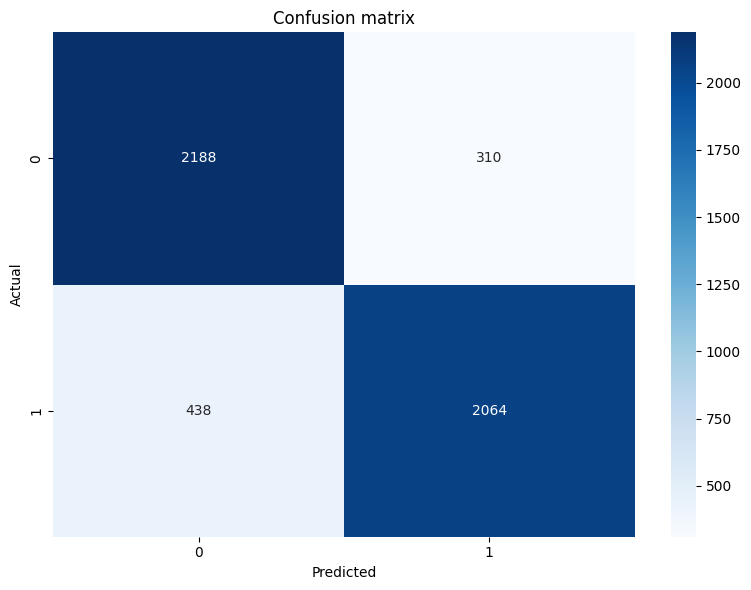

In [51]:
#Evaluate and Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

# Class labels
class_names = ["0","1"]
n_classes = len(class_names)

ax.set_title('Confusion matrix')

cm = confusion_matrix(y_test_nb, y_pred_nb)

sns.heatmap(
    cm, 
    annot=True, fmt='d', cmap='Blues', 
    xticklabels=class_names, yticklabels=class_names, ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 3.2 Model2: Baseline LSTM Classifier 

In [52]:
#Hyperparameters
vocab_size = len(vocab) + 1
embedding_dim = 128
hidden_dim = 128
output_dim = 1
dropout = 0.3
activation = "relu"
l2_reg = 1e-4            # L2 regularization strength
learning_rate = 1e-4
max_len = 256

#Model Creation
lstm_model = Sequential([
    Input((max_len,)),
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim,
        mask_zero=True      #Enabled to ignore padding tokens
    ),
    
    LSTM(hidden_dim),
    
    Dropout(dropout),
    
    Dense((hidden_dim // 2), activation=activation),
    
    Dense(output_dim, activation="sigmoid", kernel_regularizer=l2(l2_reg))
])

lstm_model.compile(
    loss=keras.losses.BinaryCrossentropy(name="binary_crossentropy"),
    optimizer=keras.optimizers.Adam(name="adam", learning_rate=learning_rate),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

lstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 256, 128)          6489088   
                                                                 
 lstm_1 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 6628993 (25.29 MB)
Trainable params: 6628993 (25.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


We can measure with accuracy due to class balance being perfect 50/50 so we can safely just measure ACC

In [53]:
#Training callbacks
callbacks = [
    ModelCheckpoint(
        './models/review_rnn_classifier.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    TensorBoard(
        log_dir='./logs/review_rnn_classifier',
        histogram_freq=1,
        write_graph=True
    )
]

In [54]:
#Train the model
#We ignore class weights due to finding out it was equal on both sides
history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=8,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/8

313/313 [==============================] - ETA: 0s - loss: 0.6051 - accuracy: 0.6800
Epoch 1: val_accuracy improved from -inf to 0.83480, saving model to ./models\review_rnn_classifier.keras
313/313 [==============================] - 124s 388ms/step - loss: 0.6051 - accuracy: 0.6800 - val_loss: 0.4292 - val_accuracy: 0.8348
Epoch 2/8
313/313 [==============================] - ETA: 0s - loss: 0.2998 - accuracy: 0.8878
Epoch 2: val_accuracy improved from 0.83480 to 0.88060, saving model to ./models\review_rnn_classifier.keras
313/313 [==============================] - 129s 411ms/step - loss: 0.2998 - accuracy: 0.8878 - val_loss: 0.3066 - val_accuracy: 0.8806
Epoch 3/8
313/313 [==============================] - ETA: 0s - loss: 0.1701 - accuracy: 0.9409
Epoch 3: val_accuracy improved from 0.88060 to 0.88380, saving model to ./models\review_rnn_classifier.keras
313/313 [==============================] - 129s 411ms/step - loss: 0.1701 - accuracy: 0.9409 - val_loss: 0.3026 - val_ac

157/157 [==============================] - 10s 54ms/step
Accuracy: 0.8838
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      2500
           1       0.89      0.87      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



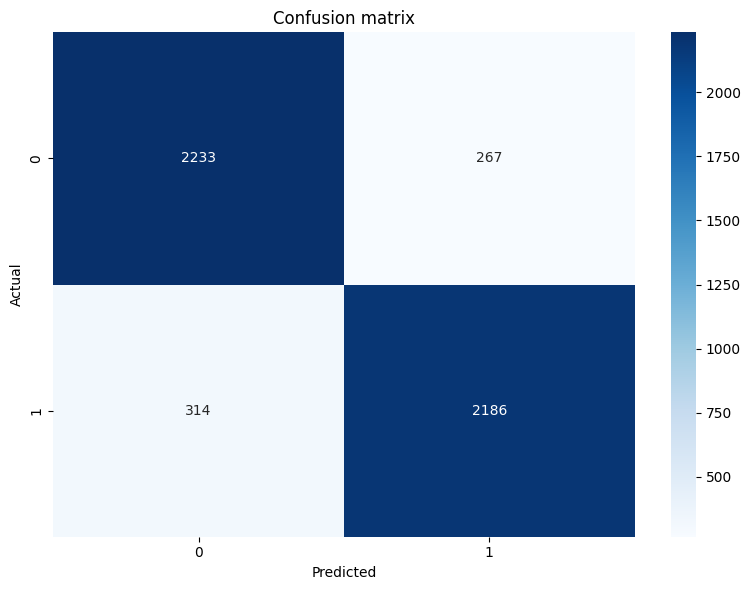

In [55]:
#Evaluate and plot CM
y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))

fig, ax = plt.subplots(figsize=(8, 6))

# Class labels
class_names = ["0","1"]
n_classes = len(class_names)

ax.set_title('Confusion matrix')

cm = confusion_matrix(y_test, y_pred_lstm)

sns.heatmap(
    cm, 
    annot=True, fmt='d', cmap='Blues', 
    xticklabels=class_names, yticklabels=class_names, ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

Our results from LSTM is slightly better than our Naive Bayes. This is expected behavior. We did notice our LSTM overfit VERY fast, on first epoch. Our data is small enough that our model memorized patterns immediately even with only 1 LSTM layer, we could try increasing  dropout if we want to make it harder for the model.

### 3.3 Model3: Pre-Trained BERT Classifier

In [ ]:
#Bert needs its own tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Prepare data
X_dbu = df_preprocess['review'].to_list()
y_dbu = df_preprocess['sentiment']

#Split
X_train_dbu, X_test_dbu, y_train_dbu, y_test_dbu = train_test_split(
    X_dbu,
    y_dbu,
    test_size=0.2,
    random_state=320
)

#Tokenize
X_train_dbu = tokenizer(
    X_train_dbu,
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="tf"
)

X_test_dbu = tokenizer(
    X_test_dbu,
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="tf"
)

print(f'Shape of inputs: {X_train_dbu["input_ids"].shape}')

Shape of inputs: (20000, 256)


In [ ]:
#Hyperparameters
MODEL_NAME = "distilbert-base-uncased"
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

# Create tf.data.Dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": X_train_dbu["input_ids"], "attention_mask": X_train_dbu["attention_mask"]},
    y_train_dbu
)).shuffle(20000).batch(BATCH_SIZE)

eval_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": X_test_dbu["input_ids"], "attention_mask": X_test_dbu["attention_mask"]},
    y_test_dbu
)).batch(BATCH_SIZE)

#Create the model
dbu_model = TFAutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=1        #Output Dim or num of classes
)


# optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
# loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
# metrics=["accuracy"]


#Alternative if you want num_labels = 1
loss=keras.losses.BinaryCrossentropy(from_logits=True)
optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE)
metrics=keras.metrics.BinaryAccuracy(name="accuracy")

dbu_model.compile(optimizer=optimizer, loss=loss, metrics=[metrics])




Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

We Went with distilbert-base-uncased model because it is smaller, faster, and almost same performance. It's good for our case since we don't necessarily need a HUGE model. Alternatively we could use the standard bert-based-uncased if we wanted to change it. We learned that pre-trained transformers output logits by default not probabilities so we had to include this in our loss and use SparseCategoricalCrossentropy. Tensorflow will automatically try to apply a softmax + cross entrophy. We also learned the learning rates for these pre-trained models need a much smaller learning rate instead of my normal guess of 1e-3. We also learned because we went back a few versions we cannot use the tf.keras we had to do the legacy import tf_keras and use that since keras wasn't installed with Tensorflow on this older version.

In [58]:
#Training callbacks
callbacks_dbu = [
    ModelCheckpoint(
        './models/review_dbu_classifier.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    TensorBoard(
        log_dir='./logs/review_dbu_classifier',
        histogram_freq=1,
        write_graph=True
    )
]

In [ ]:
#DO NOT RUN THIS UNLESS ON GPU! VERY LONG TRAIN TIME!
#Lowering batch size to 8 and max_length in the tokenizer may help
if is_training:
    history = dbu_model.fit(
        train_dataset,
        validation_data=eval_dataset,
        epochs=EPOCHS,
        callbacks=callbacks_dbu
    )

Epoch 1/3
1250/1250 [==============================] - ETA: 0s - loss: 0.3008 - accuracy: 0.8668
Epoch 1: val_accuracy improved from -inf to 0.84100, saving model to ./models\review_dbu_classifier.keras


c:\Users\gahhh\source\fullstack-projects\fullstack-projects\capstoneProjects\.venv310\lib\site-packages\transformers\generation\tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


1250/1250 [==============================] - 7168s 6s/step - loss: 0.3008 - accuracy: 0.8668 - val_loss: 0.2988 - val_accuracy: 0.8410
Epoch 2/3
1250/1250 [==============================] - ETA: 0s - loss: 0.1717 - accuracy: 0.9311
Epoch 2: val_accuracy improved from 0.84100 to 0.90800, saving model to ./models\review_dbu_classifier.keras
1250/1250 [==============================] - 5065s 4s/step - loss: 0.1717 - accuracy: 0.9311 - val_loss: 0.2400 - val_accuracy: 0.9080
Epoch 3/3
1250/1250 [==============================] - ETA: 0s - loss: 0.0921 - accuracy: 0.9694
Epoch 3: val_accuracy did not improve from 0.90800
1250/1250 [==============================] - 4493s 4s/step - loss: 0.0921 - accuracy: 0.9694 - val_loss: 0.3009 - val_accuracy: 0.9064
Restoring model weights from the end of the best epoch: 2.


We learned we had to decrease our batch size due to memory issues. The pre-trained BERT is made with ~110M parameters and using a higher batch size could cause an out-of-memory exception on run time. 

313/313 [==============================] - 317s 1s/step
Accuracy: 0.9078
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2498
           1       0.89      0.93      0.91      2502

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



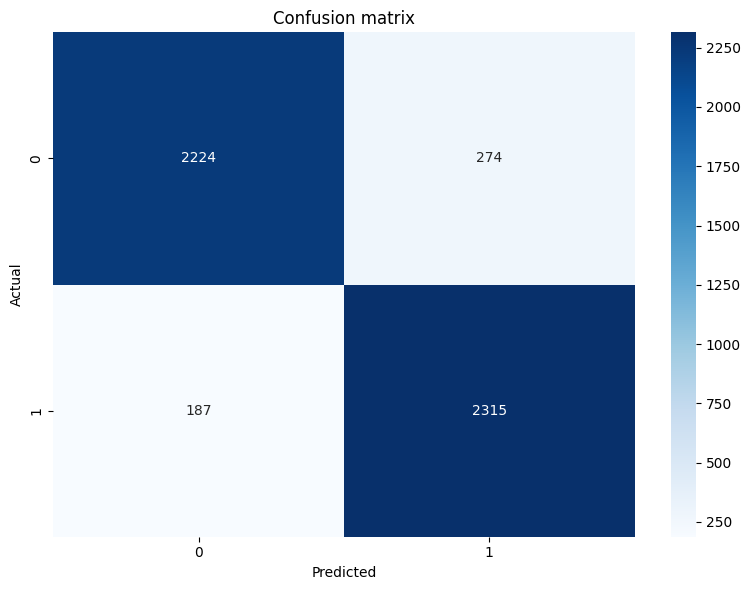

In [68]:
#Predict and evaluate
logits = dbu_model.predict(eval_dataset).logits
y_pred_dbu = np.round(tf.sigmoid(logits)).astype(int)

print("Accuracy:", accuracy_score(y_test_dbu, y_pred_dbu))
print(classification_report(y_test_dbu, y_pred_dbu))

fig, ax = plt.subplots(figsize=(8, 6))

# Class labels
class_names = ["0","1"]
n_classes = len(class_names)

ax.set_title('Confusion matrix')

cm = confusion_matrix(y_test_dbu, y_pred_dbu)

#Plot
sns.heatmap(
    cm, 
    annot=True, fmt='d', cmap='Blues', 
    xticklabels=class_names, yticklabels=class_names, ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

We learned that logits are raw, unnormalized prediction scores, hidden states, and attention weights(optional) which is why we only took that parameter in our predict we want the classification scores. We round on these to leave the y_pred_dbu as 0 and 1s. 

### 3.4 Comparative Discussion
Our results:
- model1: Accuracy: 0.850
- model2: Accuracy: 0.8838
- model3: Accuracy: 0.9078

We learned each model takes a specific way of handling each one to do the same tasks. Naive Bayes wanted the string token values for a countVectorizer to learn. LSTM wants the nltk vectorizor numerical values for it's learning to understand similarities not the bert as we mistakenly used at first. Lastly was the bert pre-trained model that needed the distilbert-base-uncased vectorizer to get its numerical vector values to learn. Each one needed an understanding of requirements and data types required, based on each model respectively. 

As far as accuracy scores go. Bert ended up being the best which makes sense for state of the art, not so simple models. Now, let's try this model on our unlabeledTestData.

## 4. Final Prediction
Use the best model to predict the unlabeledTestData(testing_df) sentiment.

In [74]:
if is_training:
    #Utilize the BERT model
    MAX_LEN = 128

    #Tokenize our data using the distilbert-base-uncased for BERT models
    unlabeled_encodings = tokenizer(
        testing_df["review"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    #Convert to tensorflow dataset
    unlabeled_ds = tf.data.Dataset.from_tensor_slices({
        "input_ids": unlabeled_encodings["input_ids"],
        "attention_mask": unlabeled_encodings["attention_mask"]
    }).batch(8)

    #Predictions
    logits = dbu_model.predict(unlabeled_ds).logits


3125/3125 [==============================] - 1814s 580ms/step


In [75]:
#Probabilities
probs = tf.sigmoid(logits)
preds = (probs > 0.5).numpy().astype(int)

print(f'Probabilities: {probs}')
print(f'\nPredictions: {preds}')

Probabilities: [[0.9961393 ]
 [0.01230455]
 [0.99009883]
 ...
 [0.0051797 ]
 [0.9930019 ]
 [0.9883585 ]]

Predictions: [[1]
 [0]
 [1]
 ...
 [0]
 [1]
 [1]]


For our probabilities we used sigmoid since we trained earlier with 1 label and its a binary problem.

In [76]:
#Add our data back into the testing_df
testing_df["predicted_sentiment"] = preds
testing_df["positive_probability"] = probs

In [81]:
#Save our results
data_dir = Path('./data')
data_dir.mkdir(parents=True, exist_ok=True)
testing_df.to_csv("./data/distilbert_predictions.csv", index=False)

In [82]:
testing_df.sample(10)

,id,review,predicted_sentiment,positive_probability
3692,8534_10,"(Spoilers warning) I cannot say enough good things about this movie. It is a great horror comedy/spoof that does everything right for a change. The humor is great and ranges from funny to so-funny-you'll-cry funny. In one scene, Ed goes edit-crazy and deletes a big scene. When his boss is looking at Ed's edit, he yells out: \Where in the fu%# is my beaver-rape scene?!?!\"" Hysterical. There are also many other great, humorous & memorable quotes and moments throughout: Ed yells out \""Don't you fu#$ing look at me!!!\"" while punching some poor schmuck repeatedly in the face. Very funny stuff. The plot of the movie itself is so ridiculous that it's priceless: Ed is a mild-mannered everyday guy that gets moved over to the horror-film editing department, and after a while goes nuts, sees monsters, and attacks people while quoting the horror movies that he has edited. This movie has it all and is simply hilarious. The DVD only costs about $7, and is a great bargain as it is the unrated widescreen cut. I own a lot of DVD's, most of which cost a lot more money than this one, but not many are as great as this movie. My Evil Ed DVD is one of the highlights of my collection and i would beat someone with a telephone receiver if they tried to steal it. Evil Ed oozes style and quality -- something that Hollywood filmmakers need to majorly learn. Evil Ed is a rare gem, and i would like to thank everyone involved in making this wonderful movie -- you did everything right, and i love Evil Ed! 10 out of 10!!!""",1,0.995454
4205,1950_1,"I had noticed this movie had been on Cinemax a lot lately, so this morning, I decided to watch it. I had just finished the Infiltrator, which is a great movie, and I thought this looked good as well. From the description the cable had, atleast. This film was awful. It's slow, the pacing is horrible, it feels as tho it lasts 4 hours. There's no real plot to speak of...agh! How can anyone say anything good about this movie. Rickman is good...but he always is...the other two characters work well, but there's no real story to support any of it. After 2 hours, and you sitting there wondering what on earth is going on, where on earth is the plot- it ends with a surprise that frankly just made me sick. Don't bother with this one.",0,0.006702
14260,8864_1,"This is a spin off of Pulp Fiction. I thought that it would be good for a few decent laughs. Well it turns out that this movie really was terrible. The whole plot doesn't follow on the Pulp Fiction plot. It turns to other movie like Forrest Gump and more. Some laughs came out of this movie, but all and all it totally took 90 minutes of my life away from me. If you are thinking of renting this movie, please don't it will waste 90 minutes of your life. Reconsider renting this and go on and find a movie that actually makes sense. Please if there is a Plump Fiction 2, I will definitely not go on and rent the sequel. Just giving a heads up for those out there.",0,0.007559
17157,507_1,"Let's see. What annoyed me most? The extra long dance scene in the beginning watching people twirling around so much I got dizzy... Without even showing where the music was coming from... All part of a college graduation that had nothing to do with the rest of the film. Or perhaps it was the fact that each scene lasted about fifteen minutes longer than they had to. What a drag this film is. And the most annoying aspect is the bad guys are so bad, so obviously horrible that it seems as if the director were making this film for second graders. \These people are bad... These people are good\"". Whenever a movie has its agenda-heart on its sleeve I am beside myself. There's a scene in a rollerskating rink that seems totally out of place. Long drawn-out love scenes with the main character and a Russian prostitute that seems more like a rock star and his sexy groupie. John Hurt's character, who is part of the overlong beginning scene

## Final Thoughts
Overall, this was a great insight into old libraries and how far they have come from the latest up-to-date versions. Also how different and niche every model is in terms of prepping the data for each model's use respectively. There isn't always a recycle and reuse approach like many older coding practices do. Paying attention to your model requires specific knowledge for THAT model. Some things may be similar, but we have to read and observe the model's pattern.